# Causal Inference
# School of Information, University of Michigan 
## Week 4

### Resources:

 - Course Manual, which can be found in Coursera
 - The research paper that inspired the question: [Kerr and Lerner, Review of Financial Studies 2014](KerrLerner2014.pdf)

## Part 1


### Background
A central question in entrepreneurial finance investigates to what extent early-stage financiers have a real impact on the firms they support (financially and otherwise). We would like to answer this question with our data that comes from one of the biggest SaaS (software as a service) investor angel groups.

The angel group is composed of 39 angel investors and each angel investor has a very hands-on role in picking ventures the group will support. After an initial screening by the staff, the entrepreneurs are then invited to give a short presentation to the angel members. Through a voting process, angel investors decide which ventures will be provided the group's support and which will not. Entrepreneurs that get votes of 20 or more angel investors are provided with investment and advice.

It should be noted that, due to strict application requirements of the angel group, characteristics of the ventures (including access to other financing opportunities) were balanced across the two sides of the voting cutoff.

### Data
For this question we will use the dataset “lecture4_RD.csv” that contains data from many SaaS (software as a service) ventures that have applied to one of the biggest angel investor groups.
 
 - *dau_mau*: daily active user/monthly active user ratio measured 15 months after the angel group voting (you can think of it as the percent of users that regularly engage with the product)
 - *revenue_g*: revenue growth rate measured 15 months after the angel group voting
 - *votes*: number of angel investor votes

In [144]:
#Import statements. Run this cell. 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
from mads.lib.path import assets

In [145]:
#Uploading data for Part 1. Run this cell.
file = assets.find("lecture4_RD.csv")
data_rd = pd.read_csv(file)

#Uncomment below and run the cell to see the first five lines of the dataframe.
data_rd.head()

,vote,dau_mau,revenue_g
0,32,0.824858,1.371313
1,0,0.030839,0.488632
2,15,0.199545,0.718289
3,28,0.652112,1.371974
4,24,0.602617,1.107473


### Questions

The voting procedure that determines which entrepreneur gets the support of the angel group provides us with the opportunity to utilize a sharp regression discontinuity design. We are interested in two measures of success: 1) daily active user to monthly active user ratio (*dau_mau*) and 2) revenue growth rate (*revenue_g*).

**Note**: You can refer to the manual for the methods we use in the assignment if you need to. 

**Use the data_rd dataframe uploaded above to answer the questions in Part 1, unless otherwise specified.**

**1.** Use the matplotlib library to plot the data for *dau_mau* against the running variable *vote* on a scatter plot, such that y-axis shows *dau_mau* and x-axis shows *vote*. (1 pt)

**Note**: This question will be manually graded

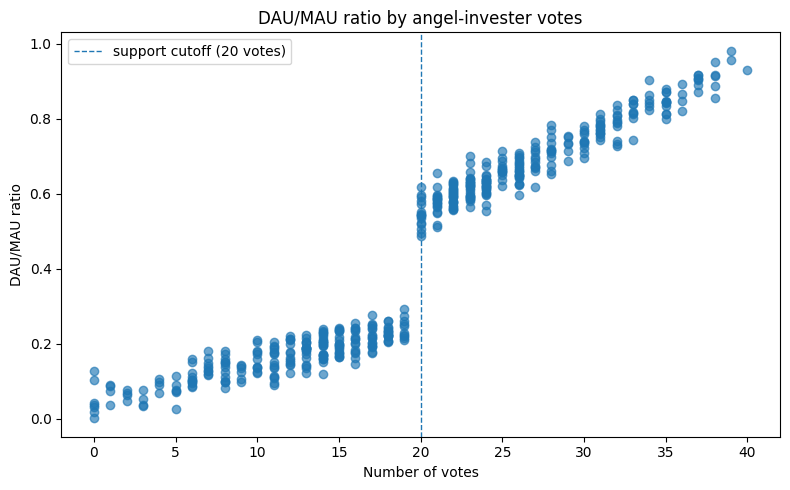

In [146]:
# plot the outcome against the original running variable 

plt.figure(figsize = (8, 5))
plt.scatter(data_rd["vote"], data_rd["dau_mau"], alpha = 0.65)
plt.axvline(20, linestyle = "--", linewidth = 1, label = "support cutoff (20 votes)")
plt.xlabel("Number of votes")
plt.ylabel("DAU/MAU ratio")
plt.title("DAU/MAU ratio by angel-invester votes")
plt.legend()
plt.tight_layout()
plt.show()

**2.** The visual shows that the relationship between *vote* and *dau_mau* is linear, yet the slope seems to differ across two sides of the cutoff. 

**2a.** Create a binary variable that takes a value of 1 if the number of votes is greater than or equal to 20, call it `D`, and add it to the data_rd dataframe. Create a running variable re-centered at the cutoff 20 (e.g. if the value of the old variable is 20, then the value of the new variable should be 0). Name it `vote_c` and add it to the data_rd dataframe. (1 pt)

**Tip**: Use `np.where()` to create the binary variable.

In [147]:
# D identifies ventures at or above the treatment cutoff

data_rd["D"] = np.where(data_rd["vote"] >= 20, 1, 0)

# re-centering makes zero represent the 20-vote cutoff
data_rd["vote_c"] = data_rd["vote"] - 20

data_rd[["vote", "D", "vote_c"]].head()

,vote,D,vote_c
0,32,1,12
1,0,0,-20
2,15,0,-5
3,28,1,8
4,24,1,4


In [148]:
# Hidden Tests, checking the values of columns D and vote_c.

**2b.** Using robust standard errors, regress *dau_mau* on *vote_c*, *D*, and the interaction of *vote_c* with *D* (i.e. *vote_c*:*D*) to account for the different slopes. Assign the coefficient in front of *D* to the variable ``d_coeff1_2_2`` and ensure that its data type is float. This is the impact of angel group’s support on the DAU/MAU ratio. (Round to four decimal places.) (1 pt)

In [149]:
# allow the slope to differ on the two sides of the cutoff
model_rd_dau = smf.ols(
    formula = "dau_mau ~ vote_c + D  + vote_c:D",
    data = data_rd
).fit(cov_type = "HC1")

# at vote_c = 0, the D coefficient is the discontinuity at the cutoff
d_coeff1_2_2 = float(np.round(model_rd_dau.params["D"], 4))

print("Estimated treatment effect on DAU/MAU:", d_coeff1_2_2)
model_rd_dau.summary()

Estimated treatment effect on DAU/MAU: 0.3016


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                dau_mau   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.410e+04
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:51:57   Log-Likelihood:                 1028.3
No. Observations:                 488   AIC:                            -2049.
Df Residuals:                     484   BIC:                            -2032.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2503      0.004     71.419      0.000       0.243       0.257
vote_c         0.0101      0.000     26.366      0.000       0.009       0.011
D              0.3016      0.005     63.532      0.000       0.292       0.311
vote_c:D       0.0098      0.001     18.580      0.000       0.009       0.011
==============================================================================
Omnibus:                        0.219   Durbin-Watson:                   1.966
Prob(Omnibus):                  0.896   Jarque-Bera (JB):                0.320
Skew:                          -0.034   Prob(JB):                        0.852
Kurtosis:                       2.894   Cond. No.                         45.0
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [150]:
# Hidden Tests, checking the value of d_coeff1_2_2.

**3.** Use the matplotlib library to plot the data for *revenue_g* against the re-centered running variable *vote_c* on a scatterplot, such that the y-axis shows *revenue_g* and the x-axis shows *vote_c*. (1 pt)

**Note**: This question will be manually graded.

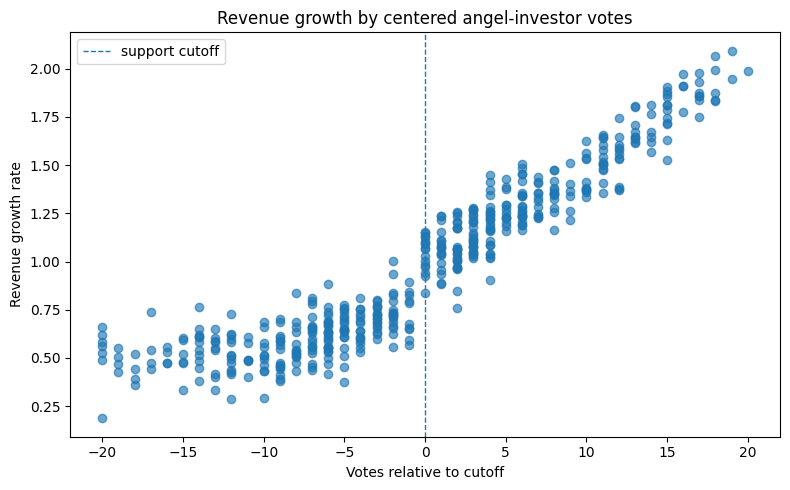

In [151]:
# inspect the functional form before choosing the RD specification 
plt.figure(figsize = (8, 5))
plt.scatter(data_rd["vote_c"], data_rd["revenue_g"], alpha = 0.65)
plt.axvline(0, linestyle = "--", linewidth = 1, label = "support cutoff")
plt.xlabel("Votes relative to cutoff")
plt.ylabel("Revenue growth rate")
plt.title("Revenue growth by centered angel-investor votes")
plt.legend()
plt.tight_layout()
plt.show()

 **4.** The visual shows that the relationship between *vote_c* and *revenue_g* is nonlinear. 
 
**4a.** Create a new column in the data_rd dataframe called `vote_c_sq` that is equal to *vote_c*$^{2}$. (1 pt)

In [152]:
# add a quadratic term to capture curvature in the running variable
data_rd["vote_c_sq"] = data_rd["vote_c"] ** 2

data_rd[["vote_c", "vote_c_sq"]].head()

,vote_c,vote_c_sq
0,12,144
1,-20,400
2,-5,25
3,8,64
4,4,16


In [153]:
# Hidden Tests, checking the values of vote_c_sq.

**4b.** Using robust standard errors, regress *revenue_g* on *vote_c*, *vote_c_sq*, and *D*. Assign the coefficient in front of variable *D* to the variable `d_coeff1_4_2` and ensure that its data type is float. This is the impact of angel group’s support on revenue growth. (Round to four decimal places.) (1 pt)

In [154]:
# estimate a quadratic RD model using all available observations
model_rd_quad = smf.ols(
    formula = "revenue_g ~ vote_c + vote_c_sq + D",
    data = data_rd
).fit(cov_type = "HC1")

d_coeff1_4_2 = float(np.round(model_rd_quad.params["D"], 4))

print("Estimated treatment effect on revenue growth:", d_coeff1_4_2)
model_rd_quad.summary()

Estimated treatment effect on revenue growth: 0.2474


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              revenue_g   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     2926.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):          1.07e-309
Time:                        00:51:58   Log-Likelihood:                 423.21
No. Observations:                 488   AIC:                            -838.4
Df Residuals:                     484   BIC:                            -821.7
Df Model:                           3                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7852      0.011     72.225      0.000       0.764       0.806
vote_c         0.0336      0.001     36.870      0.000       0.032       0.035
vote_c_sq      0.0010    4.9e-05     19.951      0.000       0.001       0.001
D              0.2474      0.017     14.798      0.000       0.215       0.280
==============================================================================
Omnibus:                        0.714   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.700   Jarque-Bera (JB):                0.547
Skew:                          -0.065   Prob(JB):                        0.761
Kurtosis:                       3.100   Cond. No.                         533.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [155]:
# Hidden tests, checking the value of d_coeff1_4_2.

**5.** Remember that another way to deal with nonlinearities is to restrict our estimation to observations close to the threshold.

**5a.** Using robust standard errors, regress *revenue_g* on *vote_c* and *D* with a bandwidth equal to 3 votes (i.e. use only observations with votes greater than or equal to 17 and less than or equal to 23). Assign the coefficient in front of variable *D* to the variable ``d_coeff1_5_1``. This is the impact of angel group’s support on revenue growth. (Round to four decimal places.) (1 pt)

In [156]:
# keep only observations within three votes of the cutoff
data_rd_bw3 = data_rd.loc[data_rd["vote_c"].abs() <= 3].copy()

# near the cutoff, a local linear specifications is less sensitive to global curvature
model_rd_bw3 = smf.ols(
    formula = "revenue_g ~ vote_c + D",
    data = data_rd_bw3
).fit(cov_type = "HC1")

d_coeff1_5_1 = float(np.round(model_rd_bw3.params["D"], 4))

# compare the two RD estimates and their robust standard errors
quad_coef = float(model_rd_quad.params["D"])
bw_coef = float(model_rd_bw3.params["D"])
quad_se = float(model_rd_quad.bse["D"])
bw_se = float(model_rd_bw3.bse["D"])

size_relation = (
    "larger in absolute value"
    if abs(bw_coef) > abs(quad_coef)
    else "smaller in absolute value"
    if abs(bw_coef) < abs(quad_coef)
    else "the same in absolute value"
)

print(
    f"Quadratic model: D = {quad_coef:.4f}, robust SE = {quad_se:.4f}\n"
    f"Bandwidth ±3 model: D = {bw_coef:.4f}, robust SE = {bw_se:.4f}\n"
    f"The reduced-bandwidth coeffcient is {size_relation} than the quadratic estimate.\n"
    f"Observations inside the bandwidth: {len(data_rd_bw3)}"
)

model_rd_bw3.summary()

Quadratic model: D = 0.2474, robust SE = 0.0167
Bandwidth ±3 model: D = 0.2488, robust SE = 0.0388
The reduced-bandwidth coeffcient is larger in absolute value than the quadratic estimate.
Observations inside the bandwidth: 129


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              revenue_g   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     213.7
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           3.23e-41
Time:                        00:51:58   Log-Likelihood:                 113.98
No. Observations:                 129   AIC:                            -222.0
Df Residuals:                     126   BIC:                            -213.4
Df Model:                           2                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7870      0.025     31.852      0.000       0.739       0.835
vote_c         0.0277      0.008      3.404      0.001       0.012       0.044
D              0.2488      0.039      6.418      0.000       0.173       0.325
==============================================================================
Omnibus:                        1.247   Durbin-Watson:                   2.110
Prob(Omnibus):                  0.536   Jarque-Bera (JB):                0.851
Skew:                          -0.173   Prob(JB):                        0.654
Kurtosis:                       3.197   Cond. No.                         11.6
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [157]:
# Hidden Tests, checking the value of d_coeff1_5_1.

**5b.** How does the size of the coefficient (round to four decimal places) in front of D compare between the nonlinear model (Part 1, Question 4b.) and the model with reduced bandwidth (Part 1, Question 5a.)? Explain why estimate precision (standard error) differs between the two models. (2 pts)  

**Note**: This question will be manually graded.

---
### STUDENT RESPONSE:

The treatment effect is nearly the same in both models: **0.2474** for the quadratic model and **0.2488** for the reduced-bandwidth model. However, the reduced-bandwidth estimate has a larger standard error because it uses fewer observations. This means the estimate is less precise, even though the estimated effect is very similar.

---

## Part 2

### Background

The Surgeon General of the US estimates that smoking during pregnancy doubles the chance a baby will be born with a low birth weight (<2500 grams). Over the past 20 years, roughly 17 percent of births are to women who smoked during this period. In recent years, many public health officials have suggested that higher cigarette taxes can be used to decrease the rate of smoking during pregnancy and consequently improve birth outcomes. On May 1 in 1994, the state of Michigan raised the cigarette tax from 25 to 75 cents per pack.


### Data

The data set “lecture4_DD.csv" has 101,676 observations. There are only three variables in the data set and variable definitions are listed below.

- *state*: 2-digit state FIPS code. Michigan is state 26, Iowa is 19.
- *smoked*: dummy variable; equal to 1 if a mother self-reported that she smoked during her pregnancy, otherwise it is equal to 0.
- *year*: observations that come from the time period
    - starting with May 1, 1992 up to April 30, 1993 is labeled as year 1
    - starting with May 1, 1993 up to April 30, 1994 is labeled as year 2
    - starting with May 1, 1994 up to April 30, 1995 is labeled as year 3 

In [158]:
# Uploading data for part 2. Run this cell
file = assets.find("lecture4_DD.csv")
data_dd = pd.read_csv(file) 

# Uncomment below to view the first five lines of the csv file for part 2
data_dd.head(5)

,state,smoked,year
0,19,0,1
1,19,0,1
2,19,0,1
3,19,0,1
4,19,0,1


### Questions

We will use the data from the Michigan “experiment” to evaluate whether higher taxes reduce smoking among pregnant women. We will be using the differences-in-differences technique, where the state of Michigan is the treatment group and another Midwestern state, Iowa, is going to constitute our control group.

**Note**: You can refer to the manual for the commands we use in the assignment if you need to. 

**Use the data_dd dataframe uploaded above to answer the questions below unless otherwise specified.**

**1.** Let’s start by visually inspecting our data for parallel trends.

**1a.** Using a scatterplot, plot pre-treatment smoking rates for Michigan and Iowa, such that the y-axis shows the rate of smoking for the pre-treatment years (years 1 and 2) that are marked on the x-axis. Use different colors for each state. Connect the smoking rate of year 1 and 2 for each state. Scale your y-axis (smoking rate) to range between 0 and 0.4 with labels for 0.2 increments. Have your x-axis (year) range from 1 to 3 with labels for each year. (2 pts)

[Notice that, within a given category, taking the means of dummy variables allows us to calculate the rate. For example, if there are 3 smokers out of 5 pregnant women, and if we have an indicator/dummy variable that takes the value of 1 for smokers and 0 for non-smoker → mean of that dummy variable = (2x0 + 3x1)/5 = ⅗ = smoker to non-smoker pregnant women ratio]

**Note**: This question will be manually graded.

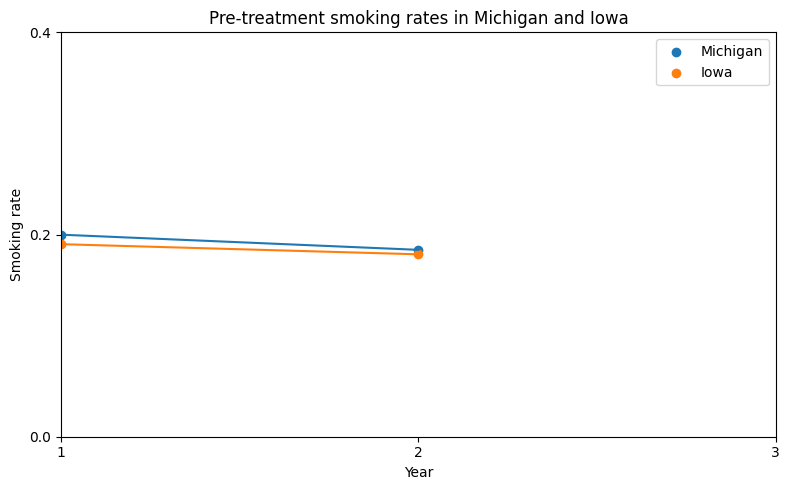

In [159]:
# calculate average smoking rates separately by state and pre-treatment year
pre_rates = (
    data_dd.loc[data_dd["year"].isin([1, 2])]
    .groupby(["state", "year"], as_index = False)["smoked"]
    .mean()
)

plt.figure(figsize = (8, 5))

for state_code, state_name in [(26, "Michigan"), (19, "Iowa")]:
    state_rates = pre_rates.loc[pre_rates["state"] == state_code].sort_values("year")
    plt.scatter(state_rates["year"], state_rates["smoked"], label = state_name)
    plt.plot(state_rates["year"], state_rates["smoked"])

plt.xlim(1, 3)
plt.xticks([1, 2, 3])
plt.ylim(0, 0.4)
plt.yticks([0, 0.2, 0.4])
plt.xlabel("Year")
plt.ylabel("Smoking rate")
plt.title("Pre-treatment smoking rates in Michigan and Iowa")
plt.legend()
plt.tight_layout()
plt.show()

**1b.**	Based on the graph, do you think that differences-in-differences is a reasonable approach to estimate the causal effect in this setting? (Hint: parallel trends assumption.) (1 pt)

**Note**: This question will be manually graded.

---

### STUDENT RESPONSE:

Yes, differences-in-differences appears reasonable because Michigan and Iowa had very similar declines in smoking rates before the tax increase. The lines are approximately parallel, which supports the parallel trends assumption. However, having only two pre-treatment periods means the assumption cannot be confirmed with certainty.

---

**2.** We will continue by creating a table [(treatment group, control group) x (pre-treatment, post-treatment)] to calculate the differences-in-differences estimate.

**2a.** Add two columns to the data_dd dataframe, a binary variable called ``treat`` (equals 1 for the data coming from the state of Michigan), and another called ``post`` (equals 1 for data coming from after the tax hike, i.e. year = 3). (1 pt)

In [160]:
# Michigan is the treated state; Iowa is the control state
data_dd["treat"] = np.where(data_dd["state"] == 26, 1, 0)

# year 3 begins after Michigan's cigarette-tax increase
data_dd["post"] = np.where(data_dd["year"] == 3, 1, 0)

data_dd[["state", "year", "treat", "post"]].head()

,state,year,treat,post
0,19,1,0,0
1,19,1,0,0
2,19,1,0,0
3,19,1,0,0
4,19,1,0,0


In [161]:
# Hidden Tests, checking the values of treat and post.

**2b.** Now calculate the corresponding means of the variable *smoked*. Assign cell entries to the corresponding variables `cell_i`, `cell_ii`, `cell_iii`.... Ensure that the data type of each variable is float. (Round the values to four decimal places.) (1 pt)

![Differences-in-differences Table](Table2_2b.png)

In [162]:
# calculate Michigan's average smoking rate before and after treatment
mi_pre = data_dd.loc[
    (data_dd["treat"] == 1) & (data_dd["post"] == 0),
    "smoked"
].mean()

mi_post = data_dd.loc[
    (data_dd["treat"] == 1) & (data_dd["post"] == 1),
    "smoked"
].mean()

# calculate Iowa's average smoking rate over the same periods
ia_pre = data_dd.loc[
    (data_dd["treat"] == 0) & (data_dd["post"] == 0),
    "smoked"
].mean()

ia_post = data_dd.loc[
    (data_dd["treat"] == 0) & (data_dd["post"] == 1),
    "smoked"
].mean()

# assign Michigan's pre-treatment, post-treatment, and change values
cell_i = float(round(mi_pre, 4))
cell_ii = float(round(mi_post, 4))
cell_iii = float(round(mi_post - mi_pre, 4))

# assign Iowa's pre-treatment, post-treatment, and change values
cell_iv = float(round(ia_pre, 4))
cell_v = float(round(ia_post, 4))
cell_vi = float(round(ia_post - ia_pre, 4))

# compare Michigan and Iowa during each period
cell_vii = float(round(mi_pre - ia_pre, 4))
cell_viii = float(round(mi_post - ia_post, 4))

# calculate the difference-in-differences estimate
cell_ix = float(round(
    (mi_post - mi_pre) - (ia_post - ia_pre),
    4
))

# organize the results into the required comparison table
table2_2b = pd.DataFrame(
    {
        "Pre-treatment": [cell_i, cell_iv, cell_vii],
        "Post-treatment": [cell_ii, cell_v, cell_viii],
        "Difference": [cell_iii, cell_vi, cell_ix]
    },
    index=[
        "Michigan (treatment)",
        "Iowa (control)",
        "Difference"
    ]
)

table2_2b

,Pre-treatment,Post-treatment,Difference
Michigan (treatment),0.1923,0.1396,-0.0527
Iowa (control),0.1856,0.1639,-0.0217
Difference,0.0067,-0.0243,-0.0310


In [163]:
# Hidden Tests, checking the values of table2_2b.

**3.** Now, we will estimate differences-in-differences through regression. Using robust standard errors, regress *smoked* on *treat*, *post*, and their interaction. Assign the coefficient in front of the interaction term to the variable `interact_coeff2_3` and ensure that its data type is float. (Round to four decimal places.) (1 pt)

In [164]:
# the interaction coefficient is the differences-in-differences estimate
model_did = smf.ols(
    formula = "smoked ~ treat + post + treat:post",
    data = data_dd
).fit(cov_type = "HC1")

interact_coeff2_3 = float(np.round(model_did.params["treat:post"], 4))

print("Differences-in-differences estimate:", interact_coeff2_3)
model_did.summary()

Differences-in-differences estimate: -0.031


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 smoked   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     129.9
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           5.36e-84
Time:                        00:51:59   Log-Likelihood:                -45883.
No. Observations:              101676   AIC:                         9.177e+04
Df Residuals:                  101672   BIC:                         9.181e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1856      0.003     58.759      0.000       0.179       0.192
treat          0.0067      0.004      1.867      0.062      -0.000       0.014
post          -0.0217      0.005     -4.049      0.000      -0.032      -0.011
treat:post    -0.0310      0.006     -5.151      0.000      -0.043      -0.019
==============================================================================
Omnibus:                    26320.260   Durbin-Watson:                   0.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            52036.891
Skew:                           1.694   Prob(JB):                         0.00
Kurtosis:                       3.894   Cond. No.                         9.77
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [165]:
# Hidden tests, checking the value of interact_coeff2_3.